# SQL in R and R Analytics


In [ ]:
# Install libraries

install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")

# Load libraries

library(sqldf)
library(dplyr)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
BASE_URL <- "https://raw.githubusercontent.com/s4ndddyy/northstar-urban-mobility-analytics/main/Cleaned/"

customers <- read.csv(paste0(BASE_URL, "customers_clean.csv"))
orders <- read.csv(paste0(BASE_URL, "orders_clean.csv"))
deliveries <- read.csv(paste0(BASE_URL, "deliveries_clean.csv"))
drivers <- read.csv(paste0(BASE_URL, "drivers_clean.csv"))
vehicles <- read.csv(paste0(BASE_URL, "vehicles_clean.csv"))
complaints <- read.csv(paste0(BASE_URL, "complaints_clean.csv"))
incidents <- read.csv(paste0(BASE_URL, "incidents_clean.csv"))
app_events <- read.csv(paste0(BASE_URL, "app_events_clean.csv"))
hubs <- read.csv(paste0(BASE_URL, "hubs_clean.csv"))

print("All cleaned datasets loaded successfully.")

[1] "All cleaned datasets loaded successfully."


# Delivery Status Analysis
This analysis evaluates overall delivery performance by examining delivery outcomes, operational costs, and route override behaviour.
The objective is to identify whether delayed or failed deliveries are associated with higher operational inefficiencies.

In [ ]:
delivery_status_analysis <- sqldf("
    SELECT
        delivery_status,
        COUNT(*) AS total_deliveries,
        ROUND(AVG(fuel_or_charge_cost), 2) AS avg_cost,
        ROUND(AVG(manual_route_override_count), 2) AS avg_overrides
    FROM deliveries
    GROUP BY delivery_status
")

delivery_status_analysis

delivery_status,total_deliveries,avg_cost,avg_overrides
<chr>,<int>,<dbl>,<dbl>
Delayed,202,13.14,1.07
Failed,132,13.15,1.04
OnTime,616,12.68,0.92


# Complaint and Delivery Relationship Analysis
This analysis investigates the relationship between customer complaints and delivery outcomes.
The objective is to determine whether failed or delayed deliveries generate higher complaint frequency and compensation costs.

In [ ]:
complaint_analysis <- sqldf("
    SELECT
        d.delivery_status,
        COUNT(c.complaint_id) AS complaint_count,
        ROUND(AVG(c.compensation_amount), 2) AS avg_compensation,
        ROUND(AVG(c.resolution_days), 2) AS avg_resolution_days
    FROM complaints c
    JOIN deliveries d
        ON c.order_id = d.order_id
    GROUP BY d.delivery_status
")

complaint_analysis

delivery_status,complaint_count,avg_compensation,avg_resolution_days
<chr>,<int>,<dbl>,<dbl>
Delayed,48,18.36,7.63
Failed,35,25.47,9.66
OnTime,149,19.18,7.60


# Driver Performance Analysis
This analysis evaluates driver-level operational performance using delivery counts, customer ratings, route overrides, and operational costs.
The objective is to identify drivers with higher operational risk or lower service quality.

In [ ]:
driver_analysis <- sqldf("
    SELECT
        d.driver_id,
        COUNT(d.delivery_id) AS total_deliveries,
        ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
        ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
        ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost
    FROM deliveries d
    GROUP BY d.driver_id
    ORDER BY avg_rating ASC
    LIMIT 10
")

driver_analysis

driver_id,total_deliveries,avg_rating,avg_overrides,avg_cost
<chr>,<int>,<dbl>,<dbl>,<dbl>
D063,3,2.37,0.33,10.40
D111,4,2.64,0.50,11.41
D076,4,2.67,1.00,14.47
D141,9,2.93,0.78,10.97
D165,6,2.98,1.33,11.04
D021,2,3.10,2.50,11.68
D147,2,3.10,1.00,19.95
D091,6,3.13,0.17,10.96
D053,7,3.14,0.86,12.29


# Zone Based Operational Analysis
This analysis compares operational performance across different delivery zones.
The objective is to identify zones experiencing higher operational pressure or inefficiencies.

In [ ]:
merged_data <- sqldf("
    SELECT
        d.*,
        o.pickup_zone,
        o.dropoff_zone,
        dr.driver_rating,
        dr.training_score,
        v.vehicle_type,
        v.maintenance_status
    FROM deliveries d
    LEFT JOIN orders o
        ON d.order_id = o.order_id
    LEFT JOIN drivers dr
        ON d.driver_id = dr.driver_id
    LEFT JOIN vehicles v
        ON d.vehicle_id = v.vehicle_id
")

In [ ]:
zone_analysis <- sqldf("
    SELECT
        pickup_zone,
        COUNT(delivery_id) AS total_deliveries,
        ROUND(AVG(delivery_duration_hours), 2) AS avg_duration,
        ROUND(AVG(customer_rating_post_delivery), 2) AS avg_rating
    FROM merged_data
    GROUP BY pickup_zone
    ORDER BY avg_duration DESC
")

zone_analysis

pickup_zone,total_deliveries,avg_duration,avg_rating
<chr>,<int>,<dbl>,<dbl>
Central,174,10.53,3.56
Riverside,119,10.04,3.87
East,156,9.64,3.91
North,135,9.19,3.90
West,114,9.09,3.90
South,139,8.98,4.05
Airport,113,8.98,3.99


# Hub Performance Analysis
This analysis evaluates the performance of operational hubs by analysing delivery duration, customer satisfaction, and delivery volume.
The objective is to identify hubs that may require operational optimisation.

In [ ]:
hub_analysis <- sqldf("
    SELECT
        h.hub_name,
        COUNT(d.delivery_id) AS total_deliveries,
        AVG(d.delivery_duration_hours) AS avg_duration,
        AVG(d.customer_rating_post_delivery) AS avg_rating
    FROM deliveries d
    JOIN hubs h
        ON d.hub_id = h.hub_id
    GROUP BY h.hub_name
    ORDER BY avg_duration DESC
")

hub_analysis

hub_name,total_deliveries,avg_duration,avg_rating
<chr>,<int>,<dbl>,<dbl>
Central Core,115,10.904134,3.676000
West Gate,127,10.330491,3.916457
Riverside Hub,115,9.918554,3.884609
Midtown Relay,128,9.819178,3.888203
North Exchange,136,9.381701,3.842059
Airport Hub,104,9.379300,3.883654
South Link,106,8.867072,3.951792
East Dock,119,7.656914,3.899496


# Service Type Failure Analysis
This analysis examines whether specific service categories experience higher delivery failures or delays.
The objective is to identify service types with increased operational risk.

In [ ]:
service_failure_analysis <- sqldf("
    SELECT
        o.service_type,
        d.delivery_status,
        COUNT(*) AS total_deliveries
    FROM orders o
    JOIN deliveries d
        ON o.order_id = d.order_id
    GROUP BY o.service_type, d.delivery_status
")

service_failure_analysis

service_type,delivery_status,total_deliveries
<chr>,<chr>,<int>
Business,Delayed,28
Business,Failed,25
Business,OnTime,73
Medical,Delayed,22
Medical,Failed,16
Medical,OnTime,70
Parcel,Delayed,49
Parcel,Failed,25
Parcel,OnTime,156


# Graph: Delivery Status Distribution
This graph visualises the distribution of delivery outcomes across the operational dataset.
The objective is to compare the frequency of on time, delayed, and failed deliveries.

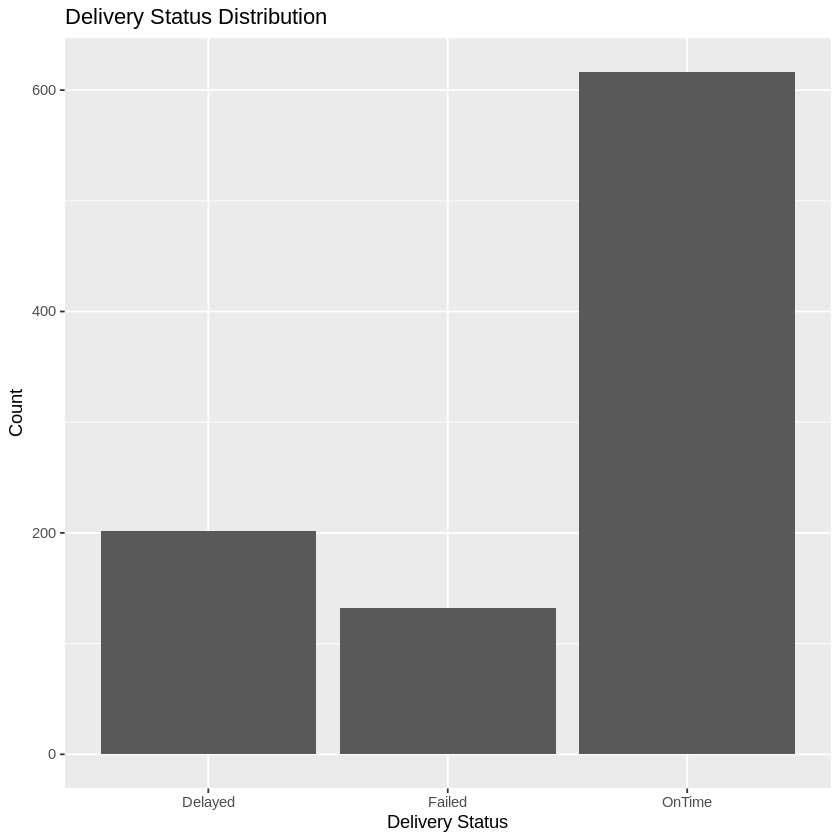

In [ ]:
ggplot(deliveries, aes(x = delivery_status)) +
    geom_bar() +
    labs(
        title = "Delivery Status Distribution",
        x = "Delivery Status",
        y = "Count"
    )

# Graph: Complaint Distribution by Delivery Status
This graph compares complaint frequency across different delivery outcomes.
The objective is to identify whether delivery disruptions correlate with increased customer complaints.

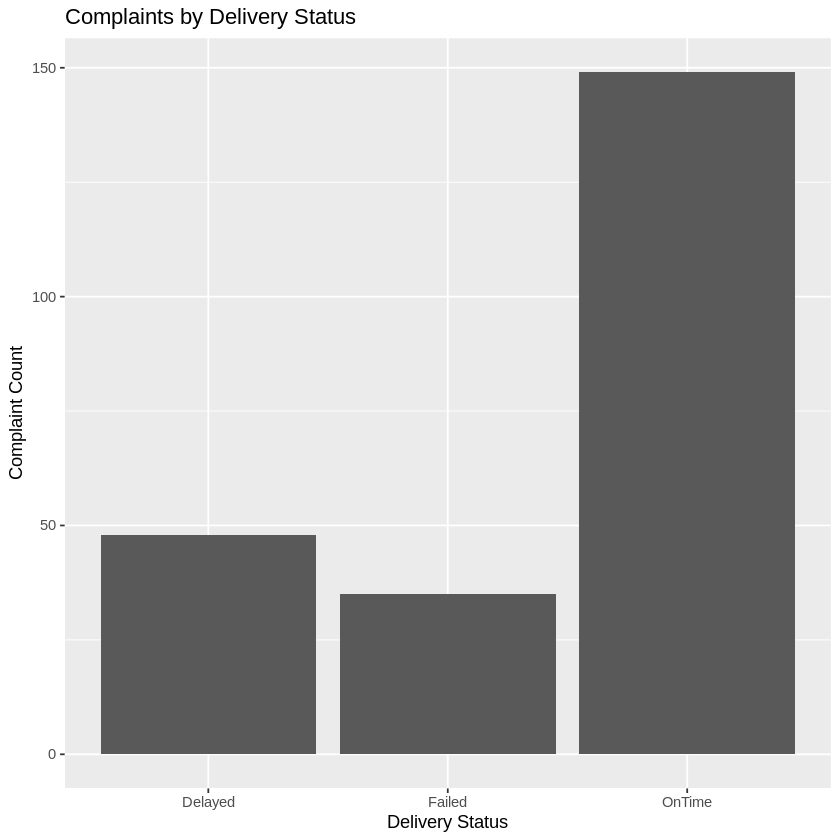

In [ ]:
ggplot(complaint_analysis,
       aes(x = delivery_status,
           y = complaint_count)) +
    geom_bar(stat = "identity") +
    labs(
        title = "Complaints by Delivery Status",
        x = "Delivery Status",
        y = "Complaint Count"
    )

# Graph: Average Delivery Duration by Zone
This chart compares average delivery duration across operational zones.
The objective is to identify zones experiencing slower operational performance.

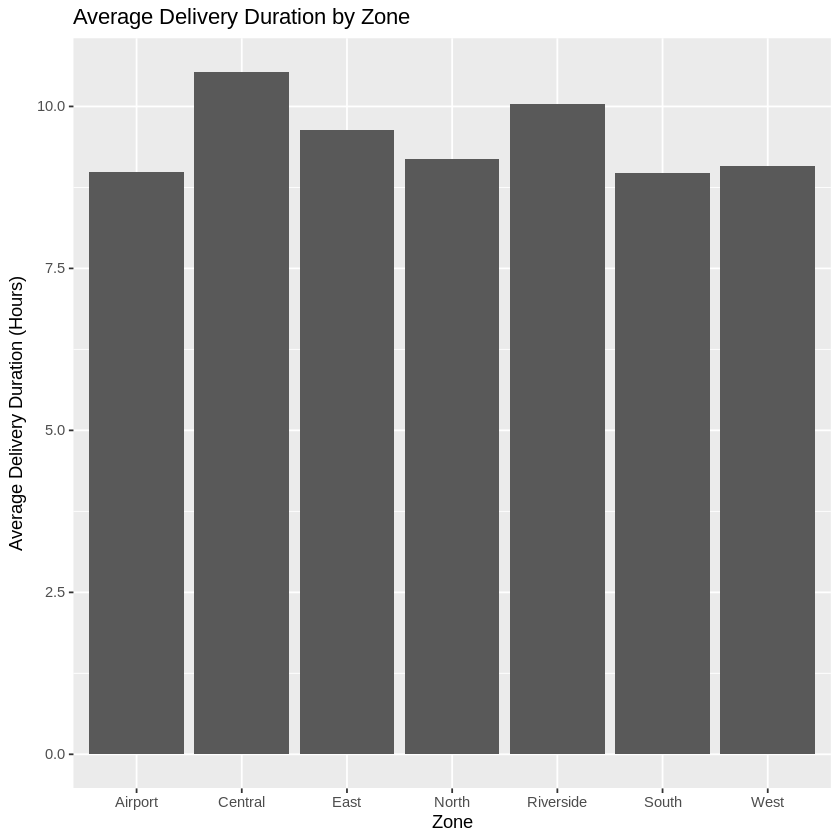

In [ ]:
zone_duration_plot <- sqldf("
    SELECT
        pickup_zone,
        AVG(delivery_duration_hours) AS avg_duration
    FROM merged_data
    GROUP BY pickup_zone
")

ggplot(zone_duration_plot,
       aes(x = pickup_zone, y = avg_duration)) +
    geom_bar(stat = 'identity') +
    labs(
        title = 'Average Delivery Duration by Zone',
        x = 'Zone',
        y = 'Average Delivery Duration (Hours)'
    )